In [1]:
import scanpy as sc
import anndata as ad
# import rapids_singlecell as rsc
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, rgb2hex

import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
import numpy as np
from sklearn.metrics import jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/0106/Hippocampus_latent_embeddings_all_single_pretrain/dmt_leiden_20250108_1.h5ad')
adata

AnnData object with n_obs × n_vars = 1112773 × 33326
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [3]:
dic = {
    '0': 'hip_0',
    '1': 'hip_1',
    '2': 'hip_2',
    '3': 'hip_1',
    '4': 'hip_3',
    '5': 'hip_4',
    '6': 'hip_1',
    '7': 'hip_0',
    '8': 'hip_5',
    '9': 'hip_6',
    '10': 'hip_5',
    '11': 'hip_6',
    '12': 'hip_7',
    '13': 'hip_2',
    '14': 'hip_1',
    '15': 'hip_8',
    '16': 'hip_6',
    '17': 'hip_8',
    '18': 'hip_6',
    '19': 'hip_2',
    '20': 'hip_2',
    '21': 'hip_3',
    '22': 'hip_5',
    '23': 'hip_4',
    '24': 'NA',
    '25': 'hip_8',
    '26': 'hip_6',
    '27': 'hip_4',
    '28': 'hip_4',
    '29': 'hip_8',
    '30': 'hip_4',
    '31': 'NA',
}
adata.obs['dmt_leiden_merge'] = [dic[i] for i in adata.obs['dmt_leiden']]


In [5]:
adata.write('/data/work/05.cluster/FuseMap/0106/Hippocampus_latent_embeddings_all_single_pretrain/dmt_leiden_20250108_1.h5ad')

In [4]:
del adata.obsm

In [5]:
del adata.uns

In [7]:
adata.obs_names_make_unique()

In [8]:
adata = adata[adata.obs.sample(frac = 0.3).index].copy()

In [12]:
adata.X = adata.X.astype(int)

In [ ]:
adata.write('/data/work/05.cluster/FuseMap/0106/Hippocampus_latent_embeddings_all_single_pretrain/dmt_leiden_20250108_1_p30.h5ad')

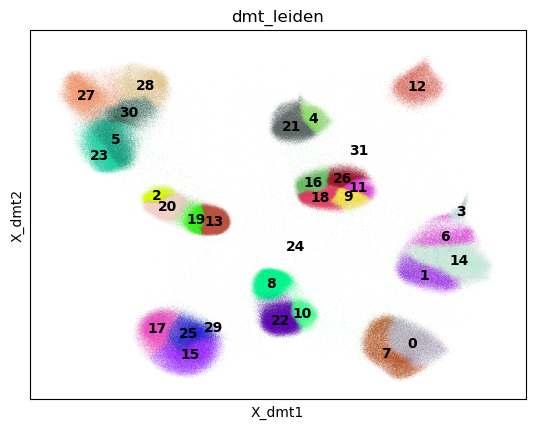

In [4]:
sc.pl.embedding(adata, basis = 'X_dmt',color = 'dmt_leiden', legend_loc = 'on data')

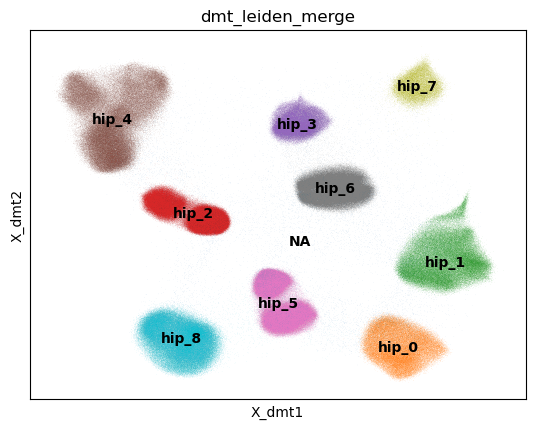

In [5]:
sc.pl.embedding(adata, basis = 'X_dmt',color = 'dmt_leiden_merge', legend_loc = 'on data')

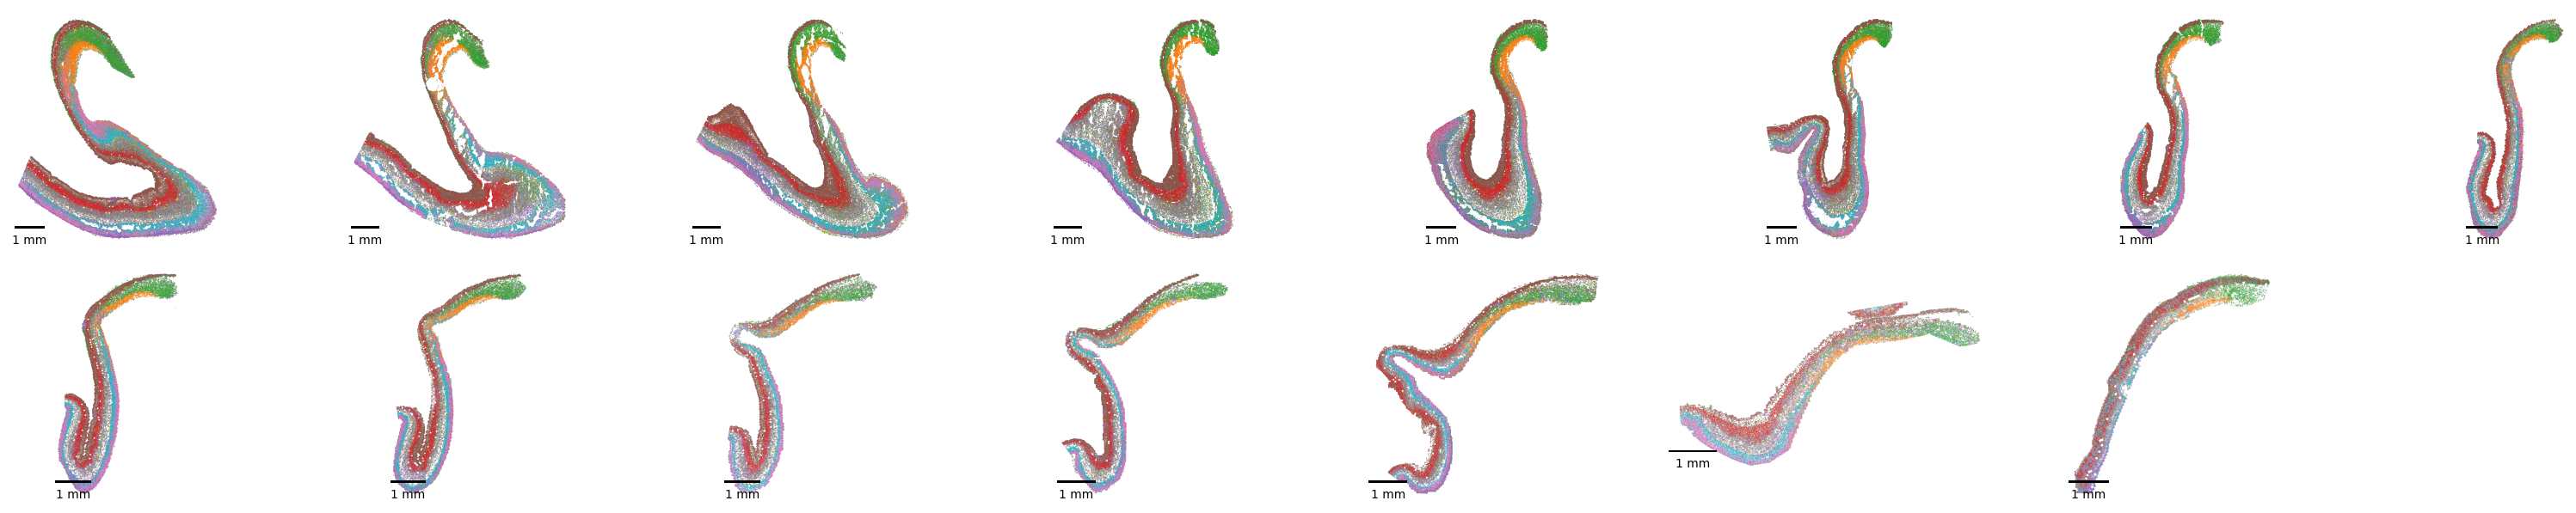

In [6]:
names = [
    '12_B03605F3G5_WT202403310048.h5ad',
    '13_B03612A1C3_WT202403310056.h5ad',
    '14_A03591A1C3_WT202403310045.h5ad',
    '16_A03592A4C6_WT202403310044.h5ad',
    '18_B03602C4D6_WT202405020031.h5ad',
    '20_B03606F3G5_WT202405020032.h5ad',
    '22_B03606C4E6_WT202403310050.h5ad',
    '23_B03609A4D6_WT202404150263.h5ad',
    '27_B03610C1E3_WT202403310051.h5ad',
    '31_B03619A1D3_WT202403310052.h5ad',
    '35_B03619E4G6_WT202403310053.h5ad',
    '39_A03589A1D4_WT202403310046.h5ad',
    '43_A03590E1G4_WT202403310064.h5ad',
    '47_A03593C1F3_WT202403310068.h5ad',
    'B03607C4E6_WT2024071214941.h5ad',
]



fig = plt.figure(figsize=(32, 12))  

gs = GridSpec(4, 8, figure=fig)  
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

    row = (count // 8) + 1  
    col = count % 8      
    count +=1
    ax = fig.add_subplot(gs[row-1, col])
    sc.pl.embedding(adata_temp, basis="align_spatial_2d", color='dmt_leiden_merge', 
                    show=False, s=1, title='', legend_loc=None, ax=ax)
    ax.axis('off')
    ax.set_aspect('equal')

    scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,);
    ax.add_artist(scalebar)

plt.tight_layout()  
plt.show()

In [8]:
sc.pp.filter_genes(adata, min_cells=50)
adata

AnnData object with n_obs × n_vars = 1112773 × 26177
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge'
    var: 'n_cells'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors', 'dmt_leiden_merge_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [9]:
sc.pp.filter_genes(adata, min_cells=100)
adata

AnnData object with n_obs × n_vars = 1112773 × 24269
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'region_hip', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge'
    var: 'n_cells'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors', 'dmt_leiden_merge_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [10]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.X.max()

5.116495684795733

In [11]:
rsc.tl.rank_genes_groups_logreg(adata, groupby = 'dmt_leiden_merge')

[W] [16:55:19.905240] L-BFGS: max iterations reached
[W] [16:55:19.908553] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.


In [12]:
csv = []
for i in set(adata.obs['dmt_leiden_merge']):
    temp = sc.get.rank_genes_groups_df(adata, group = i)[: 100]
    temp['dmt_leiden_merge'] = i
    csv.append(temp)
csv = pd.concat(csv)
csv

,names,scores,dmt_leiden_merge
0,FAM3D,0.989753,NA
1,AC004466.1,0.742649,NA
2,MLKL,0.735324,NA
3,AL358472.2,0.731230,NA
4,AL158209.1,0.707793,NA
...,...,...,...
95,AC005899.8,0.545055,hip_1
96,CCL14,0.544441,hip_1
97,FREM2,0.542841,hip_1
98,TAP1,0.542464,hip_1


In [13]:
csv.to_csv('hip.single.csv')

In [14]:
dic = {}
for i in set(adata.obs['dmt_leiden_merge']):
    temp = sc.get.rank_genes_groups_df(adata, group = i)[: 100]
    temp = temp[:10]['names'].tolist()
    dic[i] = temp

In [15]:
dic

{'NA': ['FAM3D',
  'AC004466.1',
  'MLKL',
  'AL358472.2',
  'AL158209.1',
  'TSC22D1-AS1',
  'SCN11A',
  'AL954650.1',
  'AC012213.3',
  'S100A4'],
 'hip_5': ['CRYBB3',
  'CRYBA4',
  'CRYGC',
  'CRYBA1',
  'CRYBA2',
  'CRYM',
  'CRYBB1',
  'XIST',
  'LIM2',
  'TSIX'],
 'hip_2': ['PPP1R17',
  'EOMES',
  'DPY19L1',
  'AC090159.1',
  'UBE2C',
  'PNPLA1',
  'ABCC2',
  'SIGLECL1',
  'BMP8A',
  'ACTN3'],
 'hip_0': ['NTS',
  'FOSL2',
  'NEFM',
  'ISLR2',
  'XIST',
  'LINC00486',
  'PCDH8',
  'SYT4',
  'MGAT4C',
  'ROBO1'],
 'hip_6': ['AC090791.1',
  'LINC01152',
  'MUC5B',
  'ODF3B',
  'GABRP',
  'AC004554.2',
  'AC009097.1',
  'AC130371.2',
  'AC008083.2',
  'TFAP2A'],
 'hip_3': ['TFAP2B',
  'HOXB5',
  'AC104389.5',
  'AL023583.1',
  'MAB21L1',
  'PABPC1L2A',
  'AL033528.2',
  'DERL3',
  'AL078581.2',
  'METTL27'],
 'hip_8': ['WNT7B',
  'XIST',
  'AC008403.3',
  'NR4A2',
  'COMMD2',
  'LMO3',
  'AP001007.1',
  'AC073896.3',
  'MEF2C',
  'AC024145.1'],
 'hip_7': ['FN1',
  'ITM2A',
  'IGFBP7'

In [42]:
dic = {
 'NA': ['FAM3D',  'AC004466.1',  'AL158209.1',  'AL358472.2',  'MLKL',  'AL954650.1',  'AC012213.3',  'TSC22D1-AS1',  'SCN11A',  'MEP1B'], #
    'hip_0': ['NTS',  'FOSL2',  'NEFM',  'ISLR2',  'XIST',  'LINC00486',  'PCDH8',  'SYT4',  'MGAT4C',  'HPDL'], # 
 'hip_1': ['TTR',  'NRP1',  'LINC00486',  'FOLR1',  'WFIKKN2',  'SULF2',  'PRAP1',  'SERPINF1',  'CXCL14',  'BHLHE22'],
 'hip_2': ['PPP1R17',  'AC090159.1',  'EOMES',  'DPY19L1',  'SIGLECL1',  'BMP8A',  'ABCC2',  'AC239803.3',  'ACTN3',  'PNPLA1'],
 'hip_3': ['TFAP2B',  'HOXB5',  'AL023583.1',  'AC104389.5',  'AL033528.2',  'AL078581.2',  'PABPC1L2A',  'MAB21L1',  'DERL3',  'METTL27'],
 'hip_4': ['CRYAB',  'STARD6',  'BPIFA1',  'AC093821.1',  'MEDAG',  'PPP4R1-AS1',  'AC087632.1',  'PCLAF',  'SIGLEC8',  'AC021088.1'],
 'hip_5': ['CRYBB3',  'CRYBA4',  'CRYGC',  'CRYBA1',  'CRYBA2',  'CRYM',  'LIM2',  'XIST',  'TSIX',  'CRYBB1'],
 'hip_6': ['AC090791.1',  'LINC01152',  'MUC5B',  'GABRP',  'ODF3B',  'AC004554.2',  'AC009097.1',  'AC008083.2',  'ADRB2',  'AC130371.2'],
 'hip_7': ['FN1',  'IGFBP7',  'ITM2A',  'CLDN5',  'COL4A1',  'COL4A2',  'RGCC',  'CD93',  'SLC38A5',  'ID1', 'SLC2A1'], # imm
 'hip_8': ['WNT7B',  'AL121759.1',  'AC008403.3',  'AP001007.1',  'XIST',  'AC073896.3',  'AQP3',  'AC010542.4',  'C1QL2',  'LINC02380'],
}

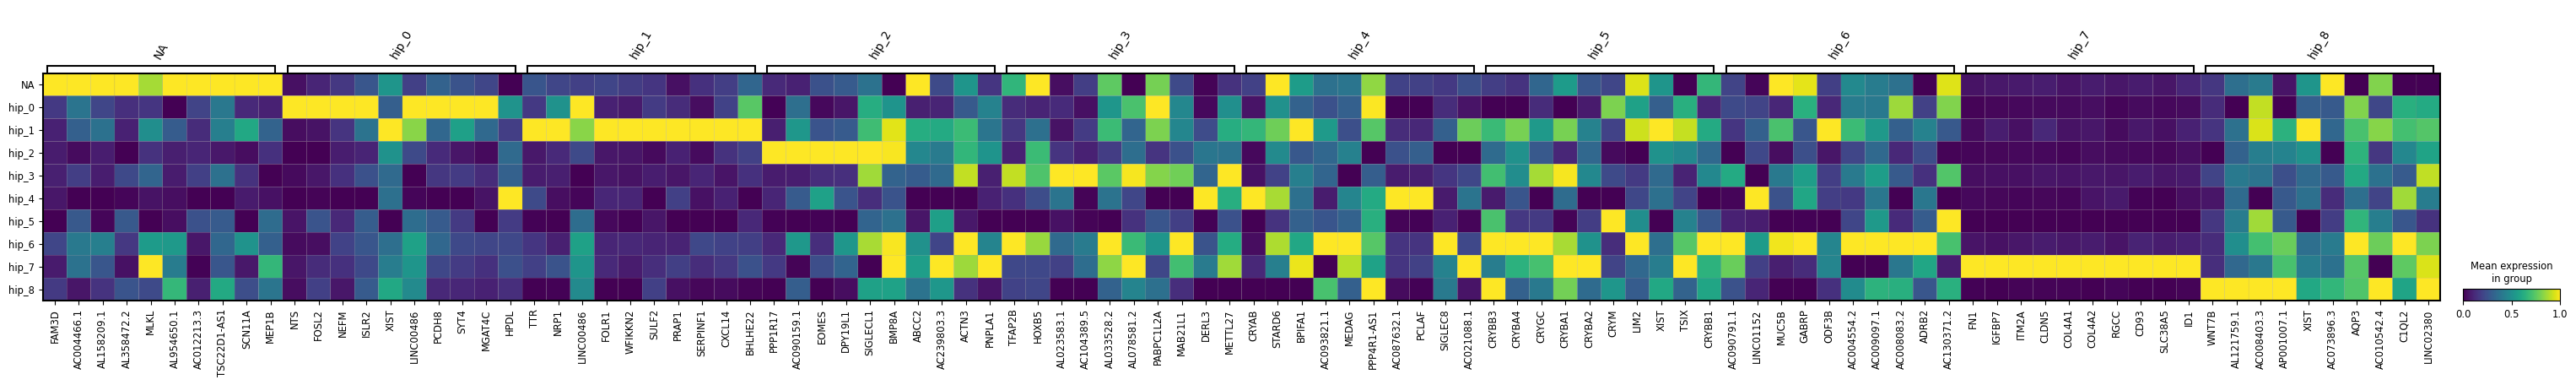

In [36]:
sc.pl.matrixplot(adata, dic, 'dmt_leiden_merge', standard_scale = 'var', var_group_rotation = 60)

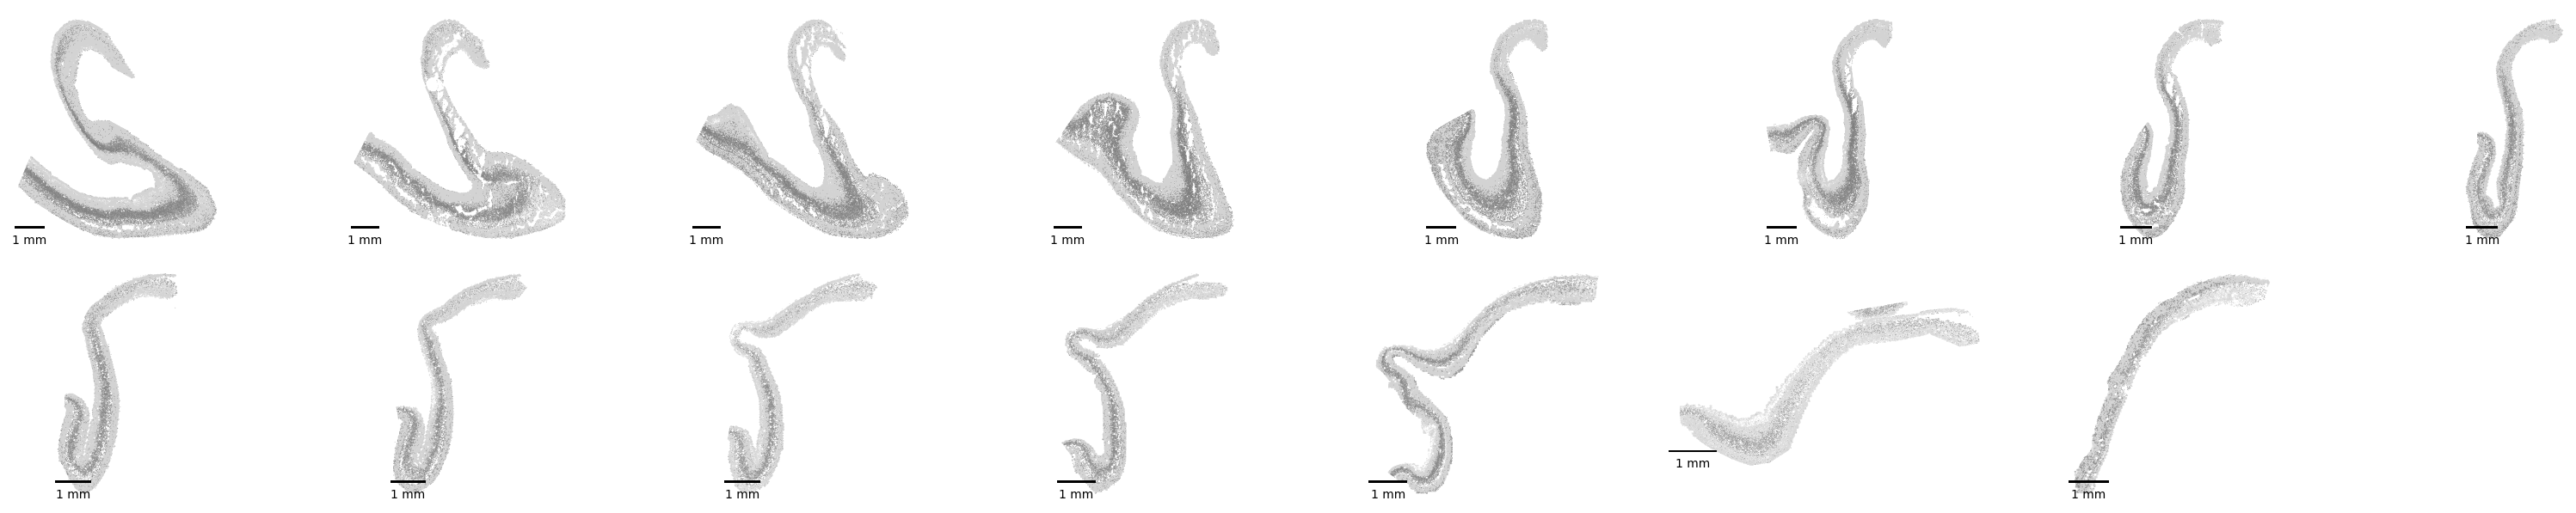

In [44]:
names = [
    '12_B03605F3G5_WT202403310048.h5ad',
    '13_B03612A1C3_WT202403310056.h5ad',
    '14_A03591A1C3_WT202403310045.h5ad',
    '16_A03592A4C6_WT202403310044.h5ad',
    '18_B03602C4D6_WT202405020031.h5ad',
    '20_B03606F3G5_WT202405020032.h5ad',
    '22_B03606C4E6_WT202403310050.h5ad',
    '23_B03609A4D6_WT202404150263.h5ad',
    '27_B03610C1E3_WT202403310051.h5ad',
    '31_B03619A1D3_WT202403310052.h5ad',
    '35_B03619E4G6_WT202403310053.h5ad',
    '39_A03589A1D4_WT202403310046.h5ad',
    '43_A03590E1G4_WT202403310064.h5ad',
    '47_A03593C1F3_WT202403310068.h5ad',
    'B03607C4E6_WT2024071214941.h5ad',
]



fig = plt.figure(figsize=(32, 12))  

gs = GridSpec(4, 8, figure=fig)  
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

    row = (count // 8) + 1  
    col = count % 8      
    count +=1
    ax = fig.add_subplot(gs[row-1, col])
    sc.pl.embedding(adata_temp, basis="align_spatial_2d", color='dmt_leiden_merge', 
                    show=False, s=1, title='', legend_loc=None, ax=ax, groups = 'hip_6')
    ax.axis('off')
    ax.set_aspect('equal')

    scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,);
    ax.add_artist(scalebar)

plt.tight_layout()  
plt.show()

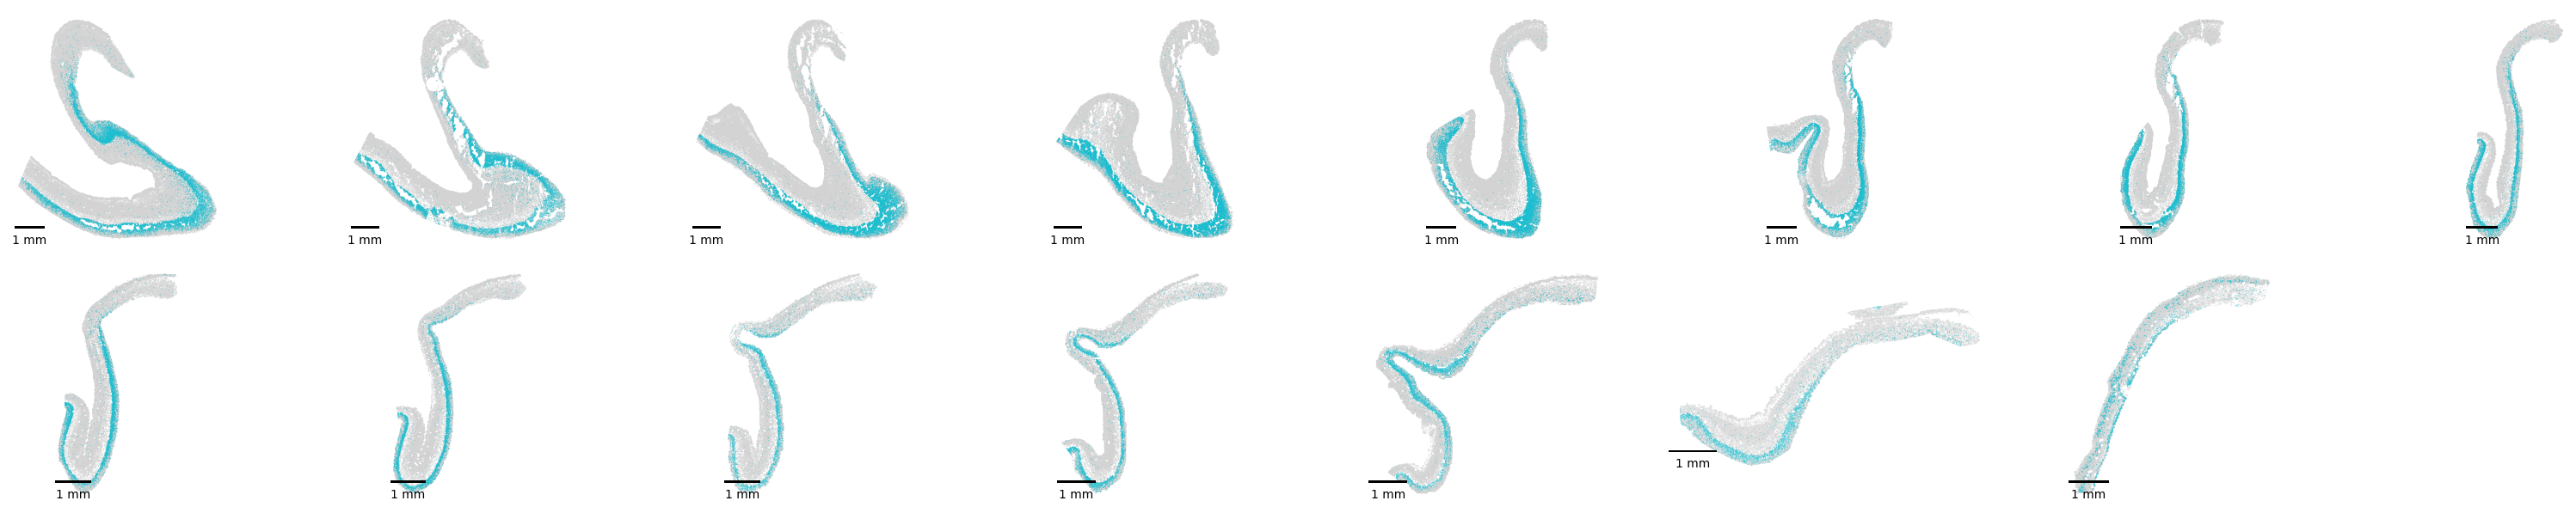

In [40]:
fig = plt.figure(figsize=(32, 12))  

gs = GridSpec(4, 8, figure=fig)  
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

    row = (count // 8) + 1  
    col = count % 8      
    count +=1
    ax = fig.add_subplot(gs[row-1, col])
    sc.pl.embedding(adata_temp, basis="align_spatial_2d", color='dmt_leiden_merge', 
                    show=False, s=1, title='', legend_loc=None, ax=ax, groups = 'hip_8')
    ax.axis('off')
    ax.set_aspect('equal')

    scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,);
    ax.add_artist(scalebar)

plt.tight_layout()  
plt.show()

In [ ]:
fig = plt.figure(figsize=(32, 12))  

gs = GridSpec(4, 8, figure=fig)  
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

    row = (count // 8) + 1  
    col = count % 8      
    count +=1
    ax = fig.add_subplot(gs[row-1, col])
    sc.pl.embedding(adata_temp, basis="align_spatial_2d", color='FN1', 
                    show=False, s=1, title='', legend_loc=None, ax=ax, cmap = 'Reds')
    ax.axis('off')
    ax.set_aspect('equal')

    scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,);
    ax.add_artist(scalebar)

plt.tight_layout()  
plt.show()

In [ ]:
fig = plt.figure(figsize=(32, 12))  

gs = GridSpec(4, 8, figure=fig)  
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

    row = (count // 8) + 1  
    col = count % 8      
    count +=1
    ax = fig.add_subplot(gs[row-1, col])
    sc.pl.embedding(adata_temp, basis="align_spatial_2d", color='AC104389.5', 
                    show=False, s=1, title='', legend_loc=None, ax=ax, cmap = 'Reds')
    ax.axis('off')
    ax.set_aspect('equal')

    scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,);
    ax.add_artist(scalebar)

plt.tight_layout()  
plt.show()

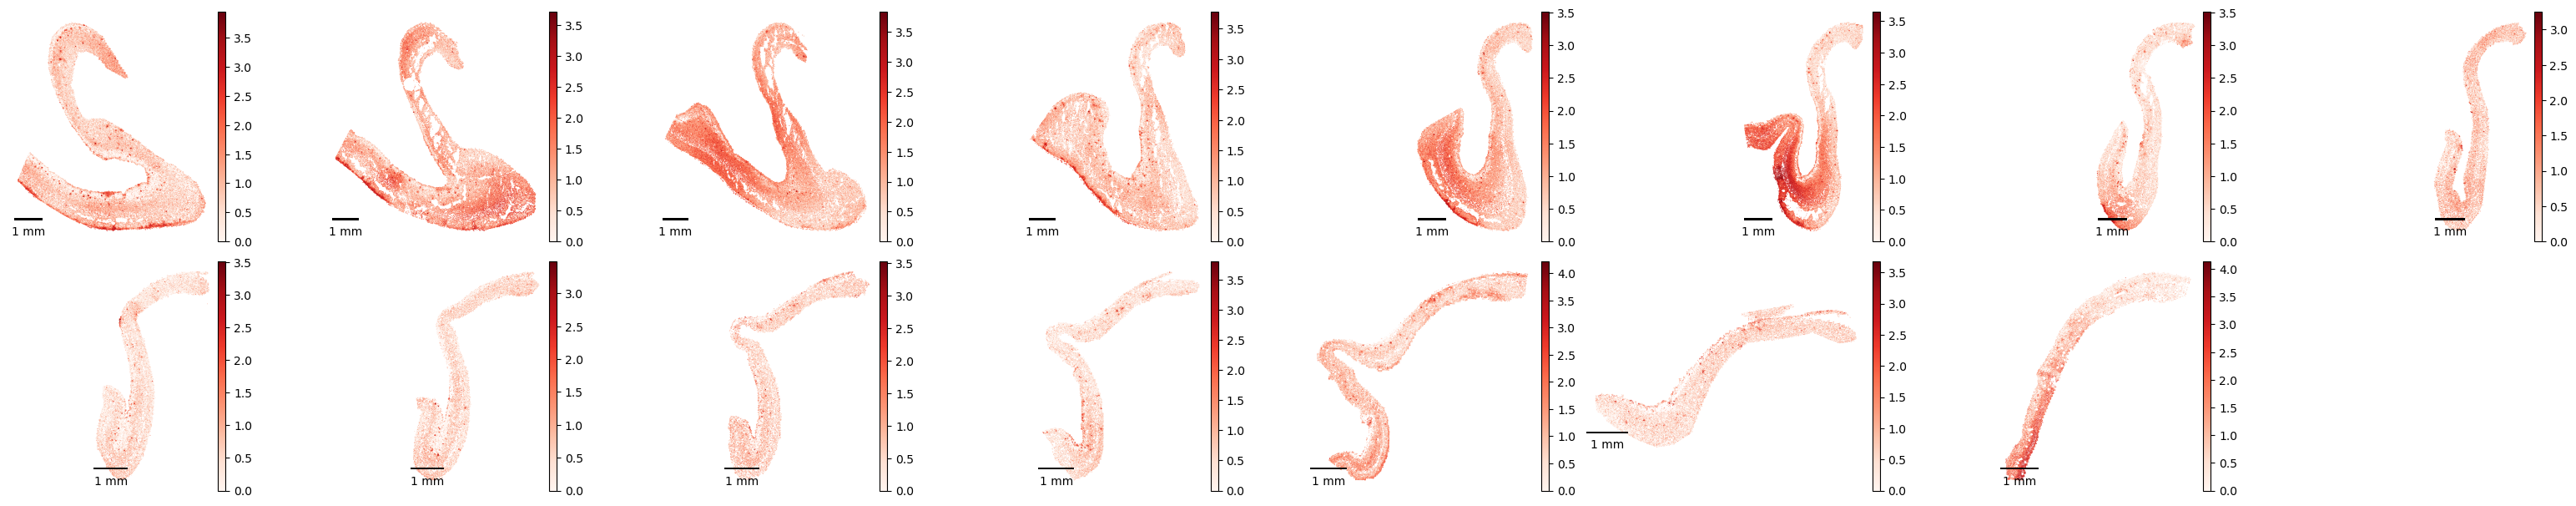

In [16]:
fig = plt.figure(figsize=(32, 12))  

gs = GridSpec(4, 8, figure=fig)  
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

    row = (count // 8) + 1  
    col = count % 8      
    count +=1
    ax = fig.add_subplot(gs[row-1, col])
    sc.pl.embedding(adata_temp, basis="align_spatial_2d", color='AC104389.5', 
                    show=False, s=1, title='', legend_loc=None, ax=ax, cmap = 'Reds')
    ax.axis('off')
    ax.set_aspect('equal')

    scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,);
    ax.add_artist(scalebar)

plt.tight_layout()  
plt.show()

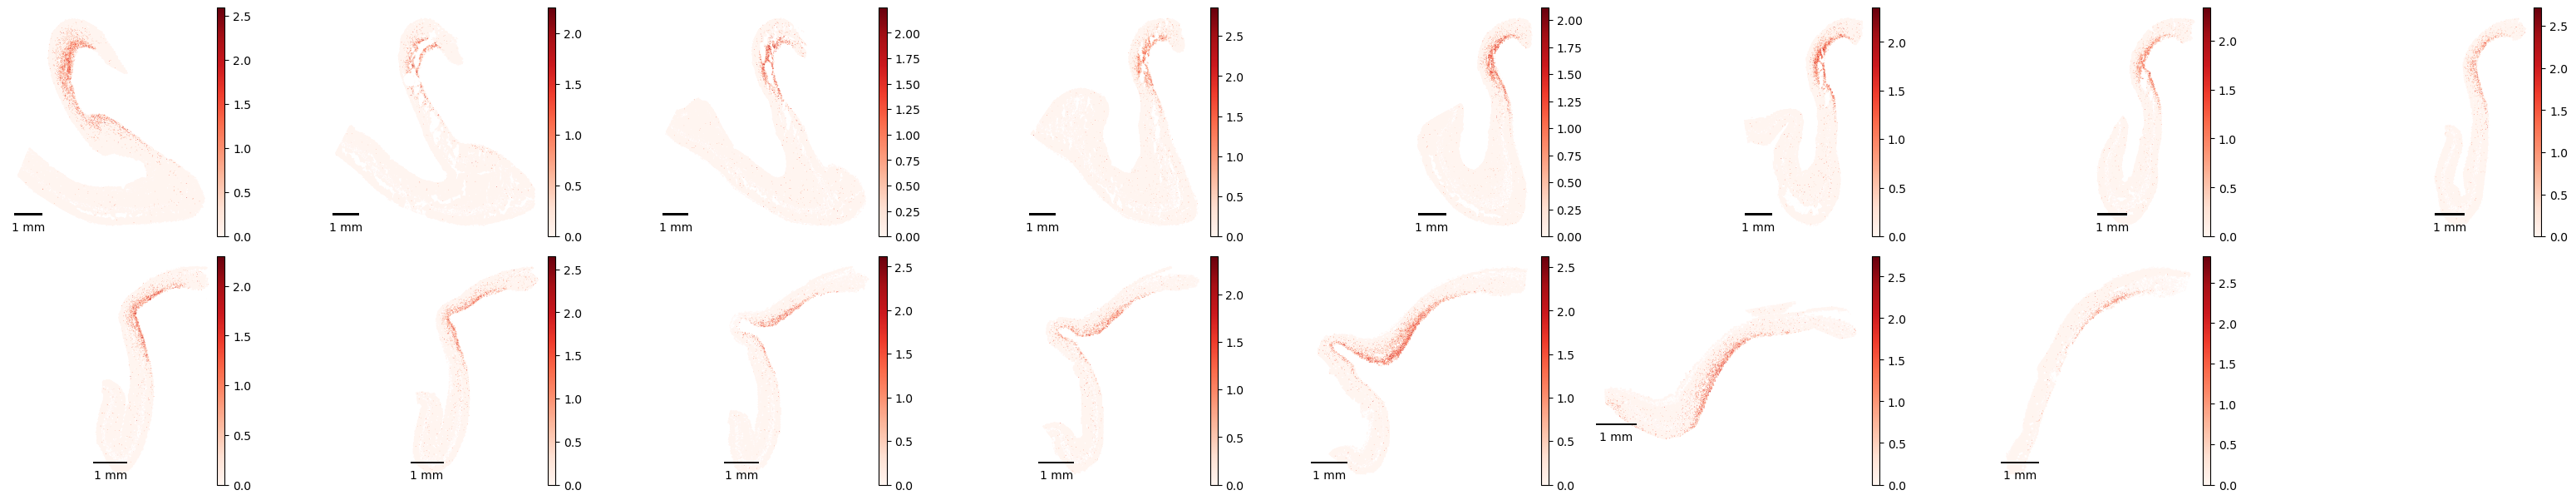

In [37]:
fig = plt.figure(figsize=(32, 12))  

gs = GridSpec(4, 8, figure=fig)  
count = 0
for name in names:
    adata_temp = adata[adata.obs['slice_code'] == name].copy()
    adata_temp.obsm['align_spatial_2d'][:, 1] = -adata_temp.obsm['align_spatial_2d'][:, 1]

    row = (count // 8) + 1  
    col = count % 8      
    count +=1
    ax = fig.add_subplot(gs[row-1, col])
    sc.pl.embedding(adata_temp, basis="align_spatial_2d", color='NTS', 
                    show=False, s=1, title='', legend_loc=None, ax=ax, cmap = 'Reds')
    ax.axis('off')
    ax.set_aspect('equal')

    scalebar = ScaleBar(0.0097, "mm", fixed_value=1, location = 'lower left', frameon = False,);
    ax.add_artist(scalebar)

plt.tight_layout()  
plt.show()